#  **Proyecto Final**

## Data Science I : Fundamentos para la Ciencia de Datos

## Objetivos :

### Estudios de Modelos Analiticos


Crearás un notebook que complemente el trabajo realizado en los siguientes apartados:

I) Elegir un método de feature selection para reducir la dimensionalidad del dataset.

II) Elegir un algoritmo de regresión o clasificación para entrenar con los datos elegidos.

III) Cálculo de métricas básicas para validar el modelo.

IV) Generar conclusiones con base en los resultados obtenidos.

# Acerca del DataSet - MetaData

## Abstract

*   El conjunto de datos de eligibilidad de tarjetas de credito proporciona informacion para comprender los factores que influyen en la elegibilidad de un individuo para una tarjeta de crédito. Este conjunto de datos contiene una variedad de criterios o caractersticas demograficas, personales y financieras que, generalmente, las instituciones financieras consideran al evaluar la posibilidad de un individuo de obtener credito.

 Cada fila del conjunto de datos representa un individuo unico, con una identificacion unica 'Id'. Cada columna representa los criterios con  los que voy a trabajar el analisis que van desde informacion demografica basica, como genero y edad, hasta caracteristicas financieras como trabajo, ingresos totales, sitacion laboral y demas. Aparte de esto la base de datos tambien contiene caracteristicas personales tanto como la cantidad de hijos, estado civil, ocupacion y educacion, lo cual nos brinda conocimiento acerca de los antecedentes y situacion de cada individuo en cuestion.
 Los investigadores, analistas e instituciones financieras pueden aprovechar este conjunto de datos para obtener información sobre los factores clave que influyen en la elegibilidad de las tarjetas de crédito y desarrollar modelos predictivos que ayuden a automatizar el proceso de evaluación crediticia. Al comprender la relación entre varios atributos y la elegibilidad de las tarjetas de crédito, las partes interesadas pueden tomar decisiones más informadas, mejorar las estrategias de evaluación de riesgos y mejorar los esfuerzos de segmentación y orientación de los clientes.

 Este conjunto de datos es valioso para una amplia gama de aplicaciones dentro de la industria financiera, incluida la gestión del riesgo crediticio, la gestión de las relaciones con los clientes y el análisis de marketing. Además, proporciona un recurso valioso para la investigación académica y con fines educativos, permitiendo a estudiantes e investigadores explorar la intrincada dinámica de la determinación de la elegibilidad para tarjetas de crédito.


 *   Conjunto de datos obtenido de: https://www.kaggle.com/datasets/rohit265/credit-card-eligibility-data-determining-factors

## **Diccionario de datos "Variables"**


*   ID: Identidad unica para cada idividuo 'cliente'.
*  Gender: Sexo del individuo. 0:hombre, 1:mujer.
*  Own_car: Caracteristica binaria que indica si el individuo tiene o no auto. 0 = no tiene ; 1 = si tiene.
*  Own_property: Caracteristica binaria que indica si el individuo es dueño de una propiedad o no. 0 = no; 1 = si.
*  Work_phone: Característica binaria que indica si la persona tiene un teléfono del trabajo. 0 = no; 1 = si.
*  Phone: Caracteristica biaria que indica si el individuo tiene telefono o no. 0 = no; 1 = si.
*  Email: Característica binaria que indica si el individuo ha proporcionado una dirección de correo electrónico. 0 = no; 1 = si.
*  Unemployed: Caracteristica binaria que indica si el individuo es desempleado. 0 = no; 1 = si.
*  Num_children: Cantidad de hijos por individuo.
*  Num_family: Cantidad de familiares que el individuo tiene.
*  Account_length: Duración de la cuenta del individuo en un banco o institución financiera.
*  Total_income: Ingresos totales del individuo.
*  Age: Edad del individuo.
*  Years_employed: Cantidad de años que el individuo ha sido empleado.
*  Income_type: Tipos de ingresos.
*  Education_type: Nivel de educacion del individuo.
*  Family_status: Estado civil del individuo.
*  Housing_type: Tipo de hogar en el que vive el individuo.
*  Occupation_type: Tipo de ocupacion que desempeña el individuo.
*  Target: Variable objetiva que indica si el individuo es elegible para una tarjeta de crédito.

## Importacion del DataSet

In [80]:
import pandas as pd

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/'

Mounted at /content/drive
/content/drive/MyDrive


In [81]:
#Pre-visualizacion del DataSet
df_CreditCards = pd.read_csv(os.path.join('Curso Coder Data Science/credit_card_eligibility_data.csv'))
df_CreditCards.head()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,5008804,1,1,1,1,0,0,0,0,2,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,5008806,1,1,1,0,0,0,0,0,2,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0
2,5008808,0,0,1,0,1,1,0,0,1,4,270000.0,52.321403,8.353354,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,0
3,5008812,0,0,1,0,0,0,1,0,1,20,283500.0,61.504343,0.000000,Pensioner,Higher education,Separated,House / apartment,Other,0
4,5008815,1,1,1,1,1,1,0,0,2,5,270000.0,46.193967,2.105450,Working,Higher education,Married,House / apartment,Accountants,0




*   Observamos que el data set tiene variables cualitativas y cuantitativas.



In [82]:
#Utilizamos el metodo shape para ver la dimension de nuestro dataset
df_CreditCards.shape

(9709, 20)

In [83]:
#Con el metodo info obersvamos los datos no nulos y verificamos si existen
df_CreditCards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9709 entries, 0 to 9708
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               9709 non-null   int64  
 1   Gender           9709 non-null   int64  
 2   Own_car          9709 non-null   int64  
 3   Own_property     9709 non-null   int64  
 4   Work_phone       9709 non-null   int64  
 5   Phone            9709 non-null   int64  
 6   Email            9709 non-null   int64  
 7   Unemployed       9709 non-null   int64  
 8   Num_children     9709 non-null   int64  
 9   Num_family       9709 non-null   int64  
 10  Account_length   9709 non-null   int64  
 11  Total_income     9709 non-null   float64
 12  Age              9709 non-null   float64
 13  Years_employed   9709 non-null   float64
 14  Income_type      9709 non-null   object 
 15  Education_type   9709 non-null   object 
 16  Family_status    9709 non-null   object 
 17  Housing_type  



*   Observamos que el DataSet no contiene elementos nulos



In [84]:
#Utilizamos el metodo describe para hacer un resumen de analisis estadistico del df_CreditCards (no me sirve para las columnas con criterio binario)
df_CreditCards.describe()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Target
count,9.709000e+03,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9.709000e+03,9709.000000,9709.000000,9709.000000
mean,5.076105e+06,0.348749,0.367700,0.671542,0.217427,0.287671,0.087548,0.174683,0.422804,2.182614,27.270059,1.812282e+05,43.784093,5.664730,0.132145
std,4.080270e+04,0.476599,0.482204,0.469677,0.412517,0.452700,0.282650,0.379716,0.767019,0.932918,16.648057,9.927731e+04,11.625768,6.342241,0.338666
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.700000e+04,20.504186,0.000000,0.000000
25%,5.036955e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,13.000000,1.125000e+05,34.059563,0.928150,0.000000
50%,5.069449e+06,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,26.000000,1.575000e+05,42.741466,3.761884,0.000000
75%,5.112986e+06,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,3.000000,41.000000,2.250000e+05,53.567151,8.200031,0.000000
max,5.150479e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.000000,20.000000,60.000000,1.575000e+06,68.863837,43.020733,1.000000


# Modelo Analitico

## Contexto Analitico


*   En este conjunto se utilizara el aprendizaje supervisado. Utilizaremos la variable target (objetivo). La variable que se desea predecir es la posibilidad de un individuo de obtener credito. Utilizaremos las features que sean excluyentes a la hora de decidir si un cliente es considerado apto para obtener credito o no.
*   Se utilizara el algoritmo de clasificacion Random Forest Classifier ya que la variable target es categorica, y como visualizaremos mas adelante, la base de datos esta muy desbalanceada.



## Contexto comercial


*   En el contexto bancario, comprender los criterios que influyen a la hora de decidir si un cliente esta capacitado para obtener credito o no es importante para prevenir deudas bancarias.
*   Un banco no puede proveer credito a un cliente sin primero asegurarse de que el cliente podra abonar lo que adeude del credito en cada mes.
*  La tarjeta de credito es una herramienta de pago que permite realizar compras y financiarlas en cuotas. A medida que se utiliza la tarjeta, se genera una deuda que debe ser cancelada mensualmente. La entidad envía un resumen con las transacciones realizadas, la fecha de vencimiento y el monto adeudado. Este importe puede ser cancelado total o parcialmente, y la deuda pendiente acumulará intereses.
*   El banco debe garantizarse de que el cliente sera capaz de pagar la deuda mensual, o al menos parcialmente en algunas ocasiones, radicada por la tarjeta de credito de el mismo.
*   Los resultados de este analisis podran ser utilizados por entes bancarias para prevenir futuras deudas y problemas externos al control de una la misma.



## Problema comercial


*   Nuestro problema se basa en como la informacion proporcionada por el modelo de clasificacion puede permitir asegurar que el cliente que quiera obtener credito realmente pueda obtenerlo. Ya que la cantidad de factores a observar al momento de elegir que cliente es o no aceptable para la obtencion de una tarjeta de credito es grande, es necesario hacer un analisis de cuales son los factores determinantes. Para eso primero hay que encontrar que factores son excluyentes para el analisis.



# Procesamiento de datos

## Importacion de librerias

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [89]:
#Importacion del DataSet
df_CreditCards = pd.read_csv(os.path.join('Curso Coder Data Science/credit_card_eligibility_data.csv'))


In [90]:
# Visualizamos las primeras dos filas
df_CreditCards.head(2)

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,5008804,1,1,1,1,0,0,0,0,2,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,5008806,1,1,1,0,0,0,0,0,2,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0


In [91]:
#Chequeamos los tipos de datos que tenemos en el DataSet
df_CreditCards.dtypes

ID                   int64
Gender               int64
Own_car              int64
Own_property         int64
Work_phone           int64
Phone                int64
Email                int64
Unemployed           int64
Num_children         int64
Num_family           int64
Account_length       int64
Total_income       float64
Age                float64
Years_employed     float64
Income_type         object
Education_type      object
Family_status       object
Housing_type        object
Occupation_type     object
Target               int64
dtype: object

In [92]:
#Eliminamos las columnas que no sean relevantes del DataSet
df_CreditCards = df_CreditCards.drop(['ID','Num_family','Phone','Email','Unemployed'],axis=1)

Columnas que no tienen relevancia para la clasificacion:


---



*   ID: Esta columna generalmente es un identificador y carece de algun poder predictivo para la variable target.
*   Num_family: El numero de familiares no debe tener ningun impacto en la eleccion de posesion de credito de un individuo.
*   Phone: Ya que es una columna binaria, no nos va a brindar informacion para el target.
*   Email: Al igual que la columna "Phone", la precencia de un mail no debe tener una relacion fuerte con la variable target.
*   Unemployed: Si bien estar empleado o desempleado puede tener cierta importancia, esta columna puede no ser muy relevante debido a la posible multicolinealidad con 'Income_type'.








In [93]:
df_CreditCards.shape

(9709, 15)

In [94]:
df_CreditCards.head(2)

,Gender,Own_car,Own_property,Work_phone,Num_children,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,1,1,1,1,0,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,1,1,1,0,0,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0


# Exploratory Data Analysis

EDA nos ayuda a comprender la distribución de los datos, las relaciones entre las características y los conocimientos importantes que pueden ayudar a comprender el conjunto de datos con claridad. Utilizamos varios gráficos para visualizar el conjunto de datos.

**¿Cual es la distribucion de la variable target?**

In [95]:
Target_Count=df_CreditCards.Target.value_counts()
Target_Count

Target
0    8426
1    1283
Name: count, dtype: int64

Text(0, 0.5, 'Frecuencia')

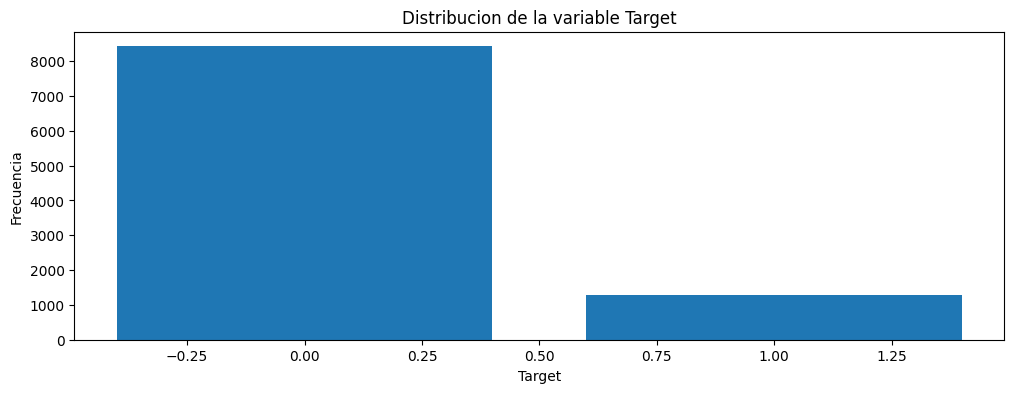

In [96]:
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(Target_Count.index, Target_Count)
ax.set_title('Distribucion de la variable Target')
ax.set_xlabel('Target')
ax.set_ylabel('Frecuencia')

*   Se observa que la diferencia entre la cantidad de individuos que pertenecen al target es significativamente menor a la cantidad de individuos que no cumplen los requisitos para pertenecer.
*   Se puede concluir en que el dataframe esta desbalanceado ya que la mayoria de los individuos en este dataframe no pueden obtener credito y su variable target indica 0.

**¿Como varia la distribucion de cantidad de tiempo siendo empleado de un individuo para considerarse o no del target?**

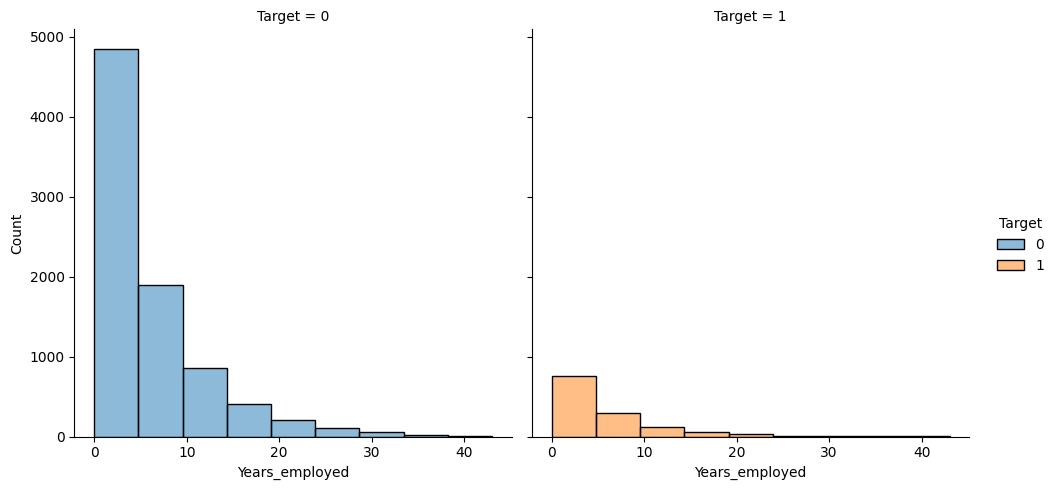

In [97]:
min_years_employed = min(df_CreditCards['Years_employed'])
max_years_employed = max(df_CreditCards['Years_employed'])
m=int(np.ceil((max_years_employed-min_years_employed)/5))

sns.displot(data = df_CreditCards, x = 'Years_employed', bins=m,hue = 'Target', col = 'Target')

En primera instancia, podemos observar que la mayoria de los individuos de la muestra tienen de 0 a 5 años empleados, esto se puede deber a que, como vimos en el metodo description, el 25% de la muestra tiene menos de 34 años. Puede asumirse que la edad debe ser crucial al momento de hablar de la cantidad de años de aportes de un individuo.
Podemos ver tambien que la cantidad de años maxima de empleados de los individuos que pertenecen al target es menor a 25, y como se puede ver en el grtafico aproximadamente menos de 100 personas de las 1283 llegaron a ese valor. Menos del 10%.
Si bien la distribucion entre el grafico de las personas que no pueden obtener credito y el de las personas que si es bastante aproximada, se podria concluir en que hay evidencia suficiente para decir que los individuos con mayor cantidad de años siendo empleados tienen menor tendencia a la posibilidad de tener credito.

**¿Como es la distribucion de sexo en la base de datos?**

In [98]:
gender_counts = df_CreditCards['Gender'].value_counts()
total_individuals = len(df_CreditCards)
male_count = gender_counts[1]
female_count = gender_counts[0]

<function matplotlib.pyplot.show(close=None, block=None)>

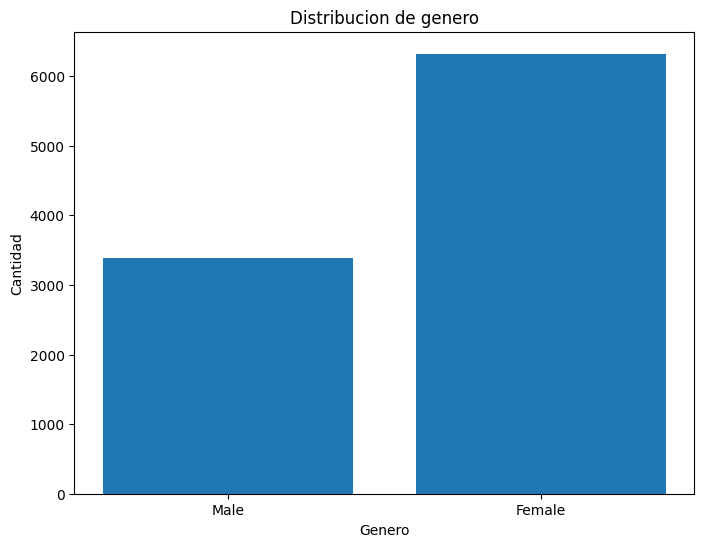

In [99]:
plt.figure(figsize=(8,6))
plt.bar(['Male', 'Female'], [male_count, female_count])
plt.title('Distribucion de genero')
plt.xlabel('Genero')
plt.ylabel('Cantidad')
plt.show




*   Hay desbalance de genero en los datos



**¿Cual es la distribucion de edades de los datos?**

Text(0, 0.5, 'Frecuencia')

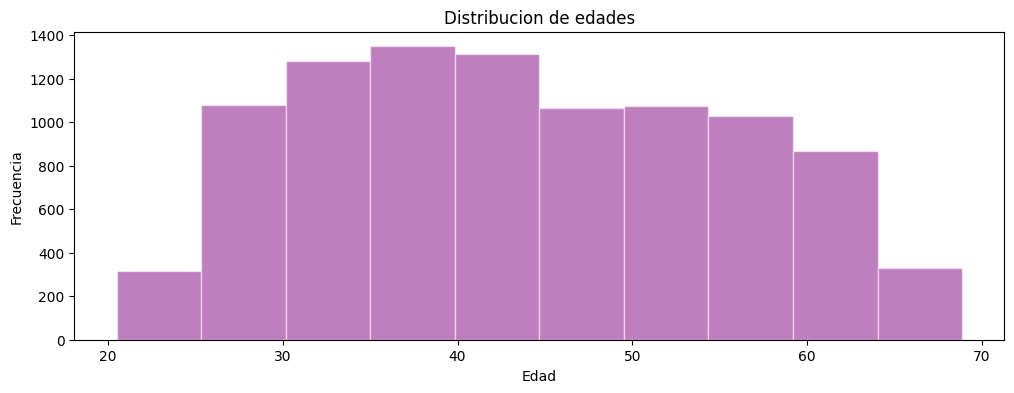

In [100]:
min_edad = min(df_CreditCards['Age'])
max_edad = max(df_CreditCards ['Age'])
n = int(np.ceil((max_edad - min_edad)/5))
plt.figure(figsize=(12,4))
plt.hist(df_CreditCards['Age'], bins=n, color='purple', edgecolor='white', alpha=0.5)

plt.title('Distribucion de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

*   Se puede observar que la minoria de los individuos se encuentran a los extremos de la distribucion. Los datos estan levemente distribuidos asimetricamente hacia la izquierda.
*   Los datos siguen una distibucion aproximadamente normal

**Distribucion de empleos de los individuos**



*   Distribucion de empleos de quienes pertenecen al target.



In [101]:
data_ocupaciones_target=df_CreditCards[df_CreditCards['Target']==1].Occupation_type.value_counts()
data_ocupaciones_target

Occupation_type
Other                    370
Laborers                 225
Core staff               128
Managers                 111
Sales staff              110
Drivers                   89
High skill tech staff     50
Medicine staff            45
Accountants               39
Security staff            30
Cooking staff             28
Cleaning staff            20
Low-skill Laborers        11
Private service staff     10
Secretaries                5
Waiters/barmen staff       5
HR staff                   3
Realty agents              2
IT staff                   2
Name: count, dtype: int64

Text(0.5, 1.0, 'Piechart de distribucion de tipos de empleo para target')

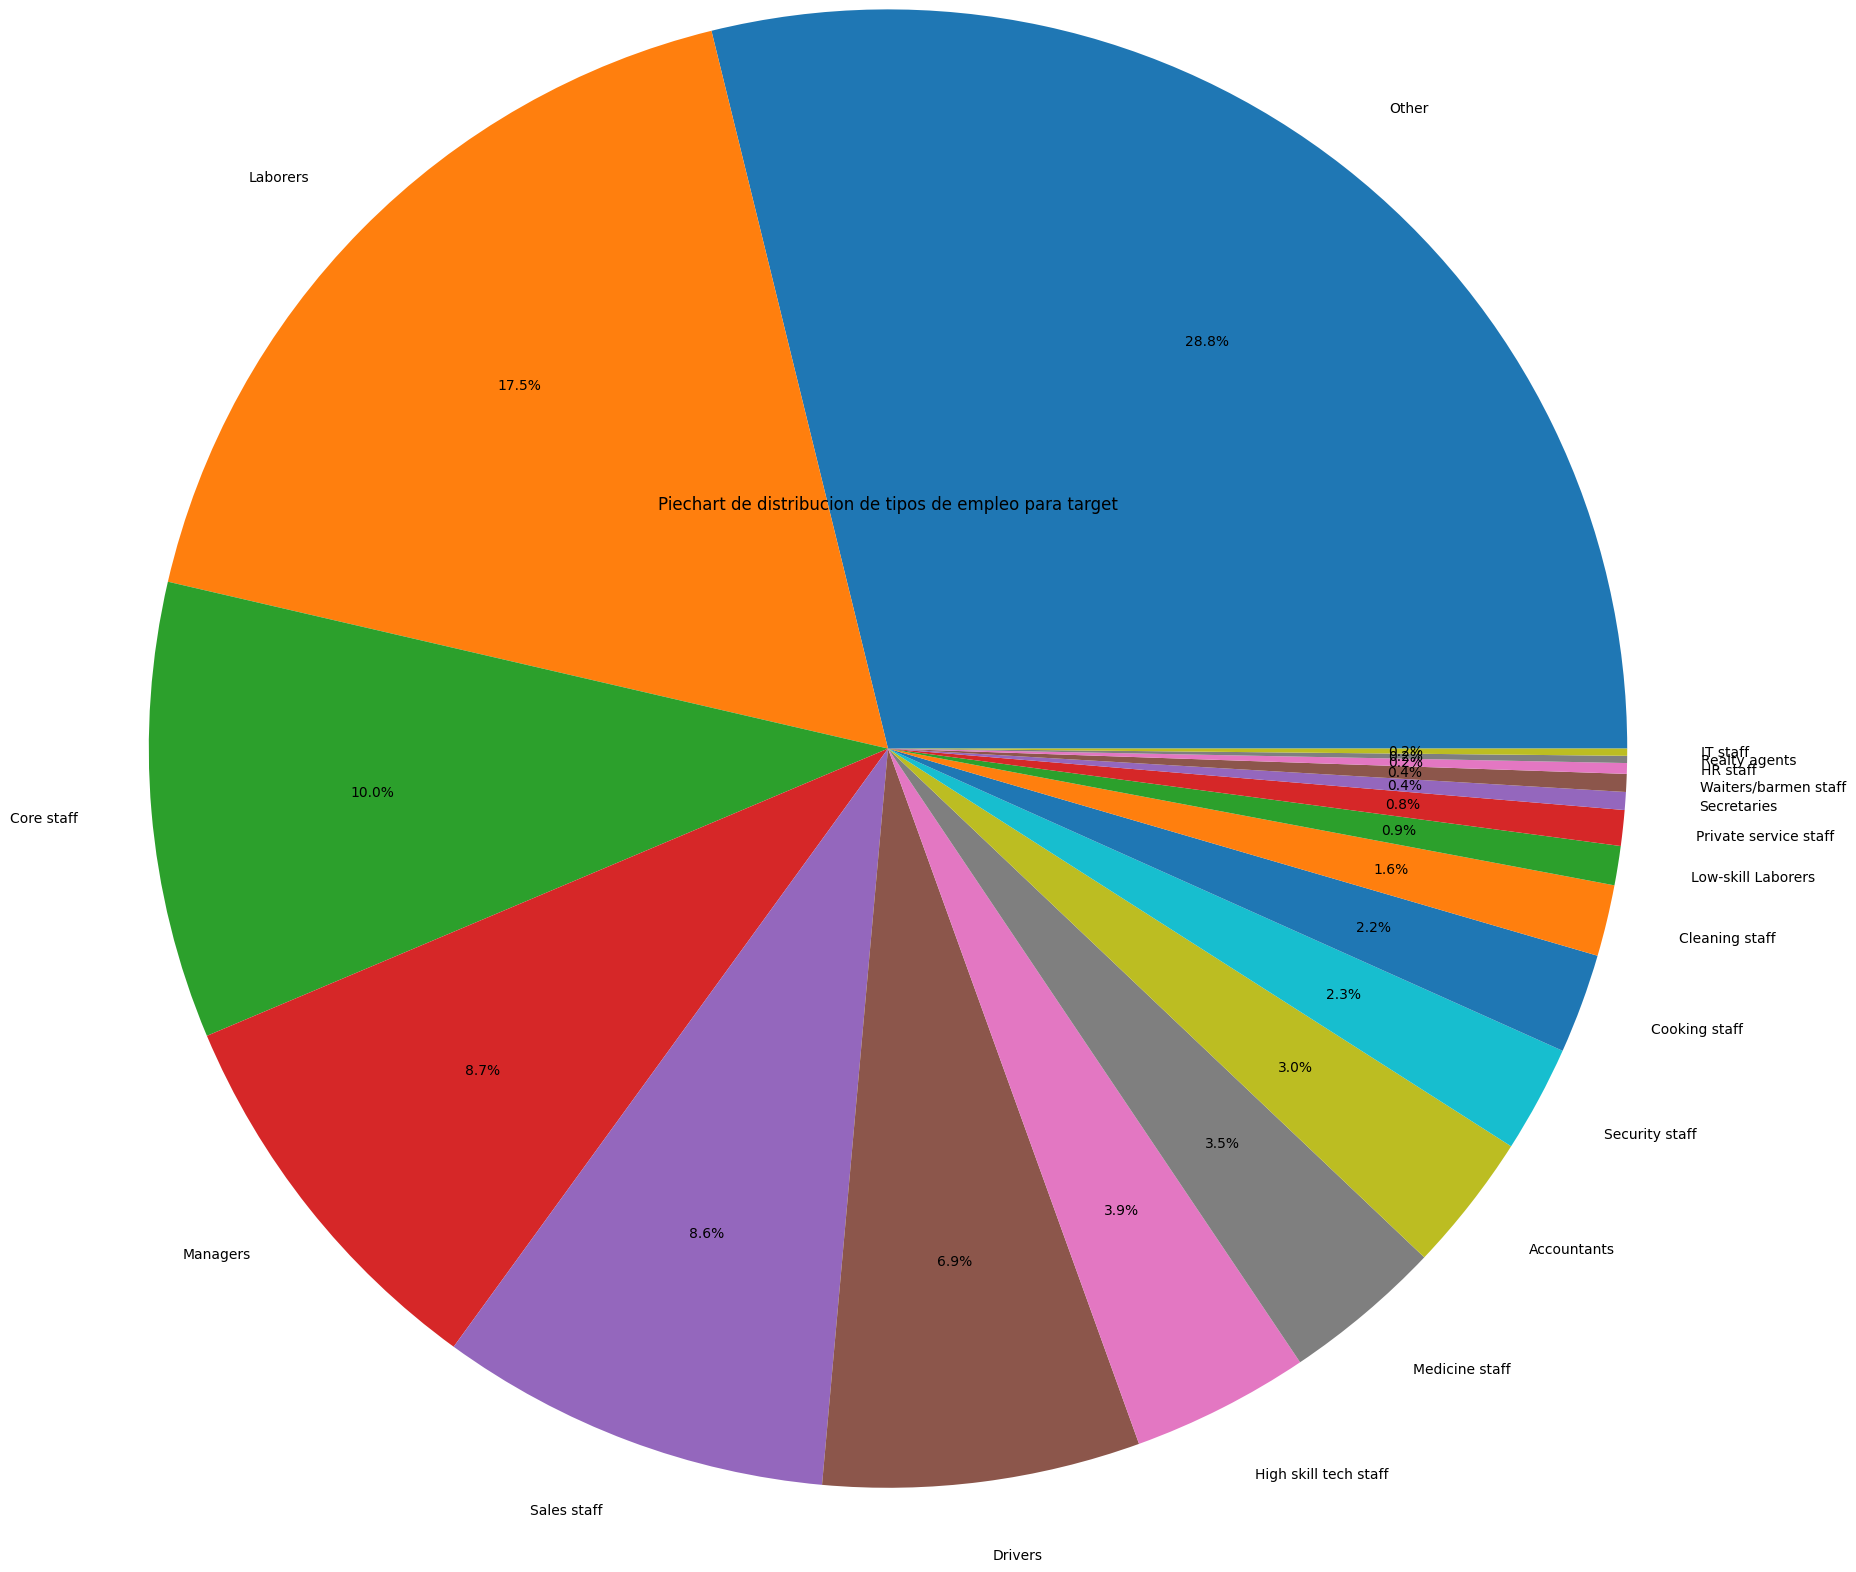

In [102]:
#Realizo un pie chart lo suficientemente grande para que no se pisen las variables.
fig,ax = plt.subplots(figsize =(10, 6))
ax.pie(data_ocupaciones_target, labels = data_ocupaciones_target.index,autopct='%1.1f%%',pctdistance=0.7, radius=4)
ax.set_title('Piechart de distribucion de tipos de empleo para target')

*  Distribucion de empleos de los individuos que no pertenecen al target.

In [78]:
data_ocupaciones_no_target=df_CreditCards[df_CreditCards['Target']==0].Occupation_type.value_counts()
data_ocupaciones_no_target

Occupation_type
12    2624
8     1499
15     849
3      749
10     671
4      534
6      307
0      261
11     246
2      165
17     152
1      126
13      76
9       42
16      41
18      35
5       19
7       16
14      14
Name: count, dtype: int64

Text(0.5, 1.0, 'Piechart de distribucion de tipos de empleo para quienes no corresponden al target')

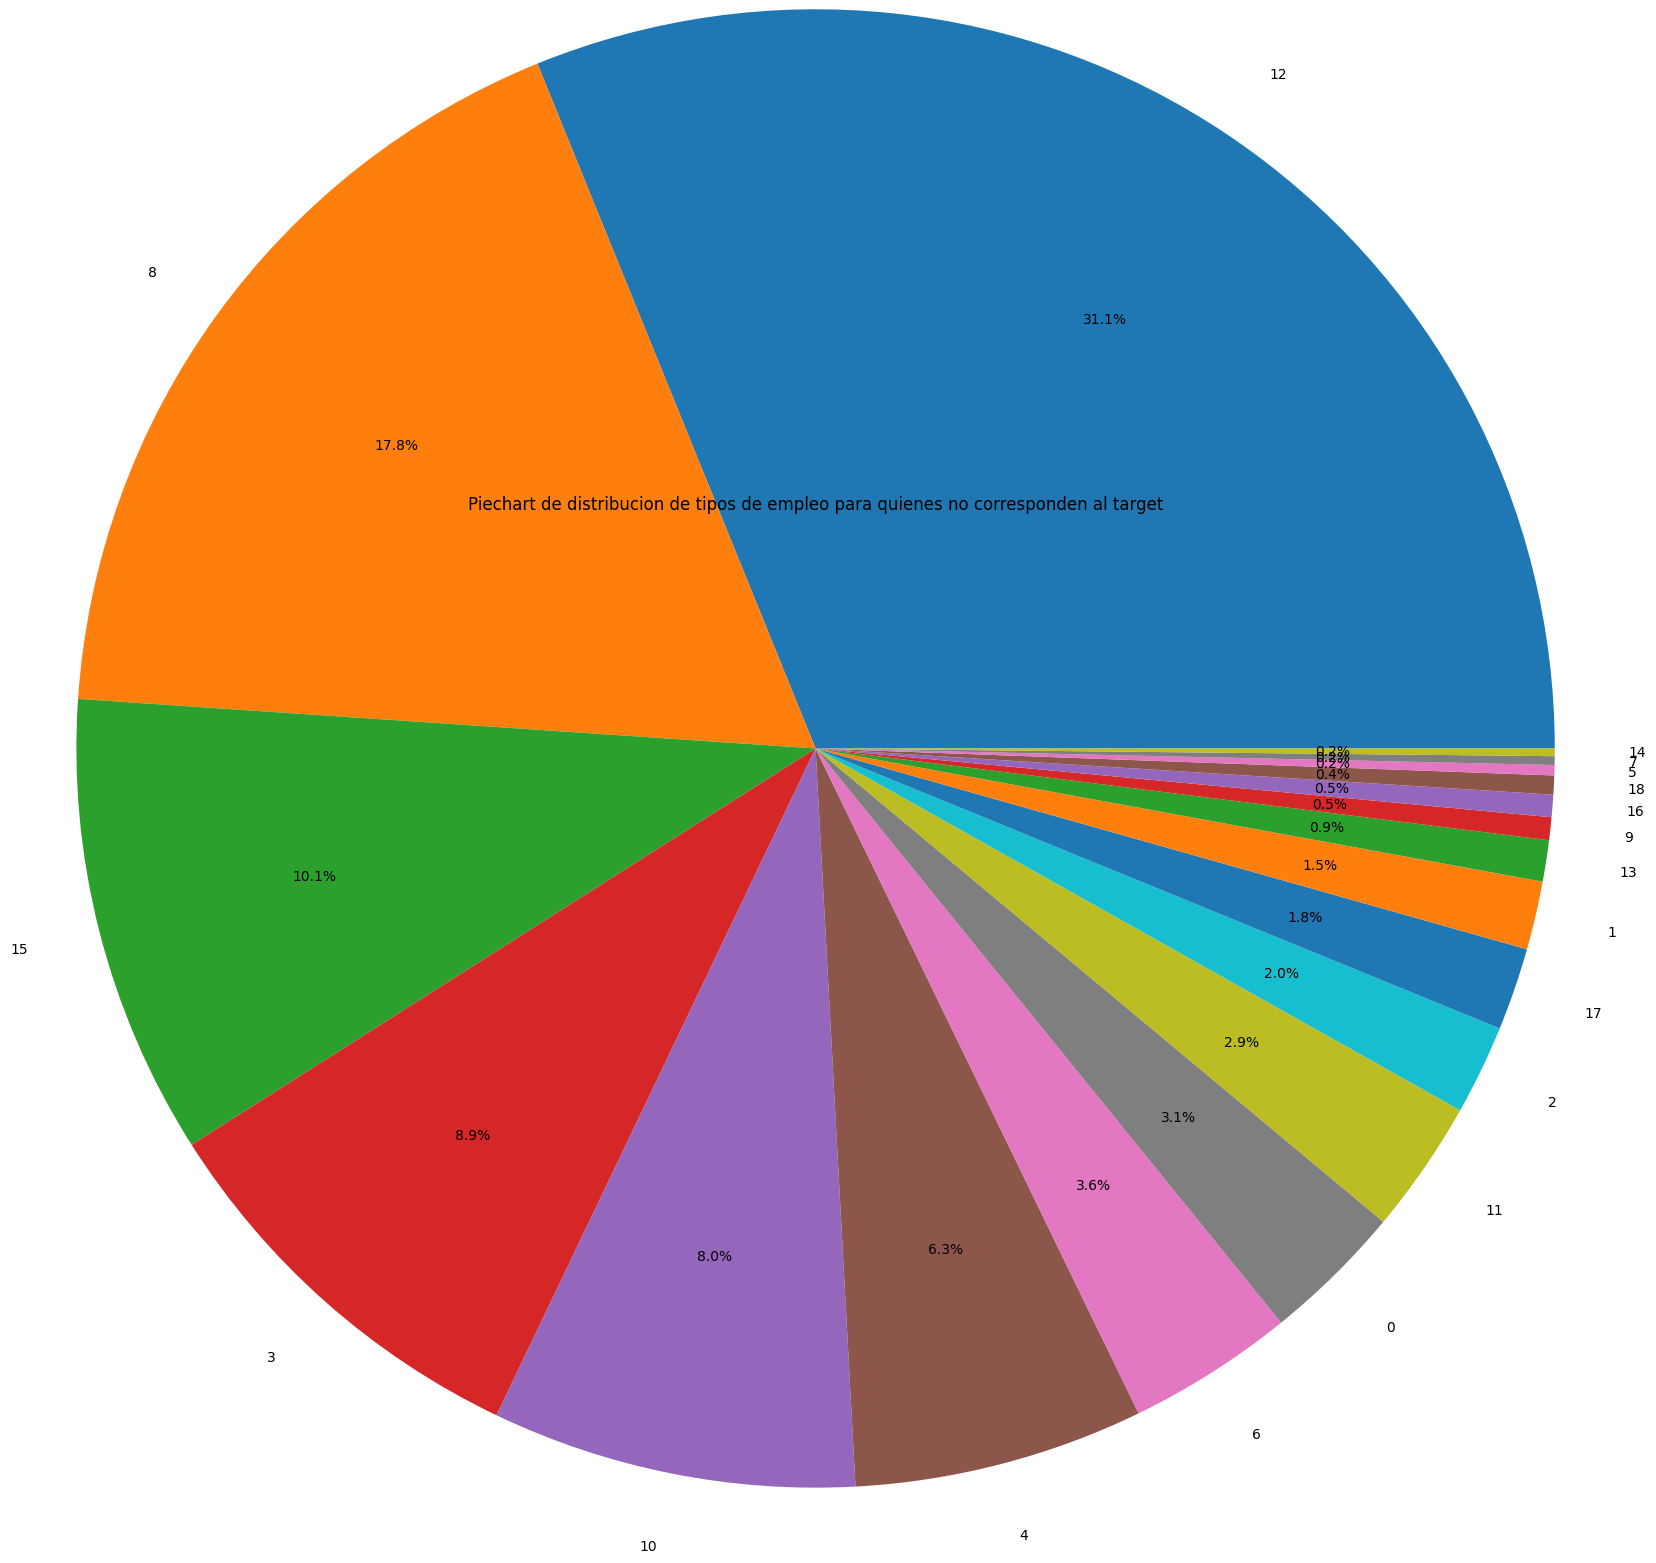

In [79]:
#Realizo un pie chart lo suficientemente grande para que no se pisen las variables.
fig,ax = plt.subplots(figsize =(10, 6))
ax.pie(data_ocupaciones_no_target, labels = data_ocupaciones_no_target.index,autopct='%1.1f%%',pctdistance=0.7, radius=4)
ax.set_title('Piechart de distribucion de tipos de empleo para quienes no corresponden al target')

# Machine Learning

## Aprendizaje supervisado

*   Modelo de clasificacion


## Random Forest Classifier


*   Se espera identificar entre los nuevos clientes aqueellos que son aptos para obtener credito y aqueellos que no. Para eso, utilizaremos el metodo Random Forest Classifier.
*   Vamos a utilizar este metodo ya que, como vimos, nuestro DataFrame esta desbalanceado y el algoritmo mismo ya tiene su argumento dentro que ajusta el sampleo de clases.
*   Este metodo clasificara a los invididuos que puedan obtener credito y a los que no estimando una relacion entre la variable objetivo Target y las variables independientes.
*   De esta manera, podremos predecir si un cliente puede o no obtener credito.





In [103]:
# Desactivar advertencias
import warnings
warnings.filterwarnings("ignore")

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score, recall_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

### Preprocesamiento de datos

*   Transformamos las variables categoricas para poder utilizarlas para la clasificacion.

In [105]:
# Asignamos los datos del dataframe a una nueva variable data para la utilización en este modelo
data = df_CreditCards

In [106]:
le = LabelEncoder()
categorical_columns = ['Income_type', 'Education_type', 'Family_status', 'Housing_type',
       'Occupation_type']
for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

In [107]:
data.shape

(9709, 15)

### Preview



*   Previsualizamos los elementos que se utilizaran en el modelo de clasificacion K-NN



In [108]:
# Imprimimos las primeras dos filas para ver las columnas a utilizar y los datos de manera previa
data.head(2)

,Gender,Own_car,Own_property,Work_phone,Num_children,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,1,1,1,1,0,15,427500.0,32.868574,12.435574,4,1,0,4,12,1
1,1,1,1,0,0,29,112500.0,58.793815,3.104787,4,4,1,1,17,0


### Feature Selection



*   Vamos a usar el 80% de los datos para Train y el 20% para Test.



In [110]:
#X contendra los diferentes features values e y contendra la variable objetivo Target.
X = data.drop('Target', axis=1)
y = data['Target']

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [112]:
print('Training Features Shape:', X_train.shape)
print('Training Labels Shape:', y_train.shape)
print('Testing Features Shape:', X_test.shape)
print('Testing Labels Shape:', y_test.shape)

Training Features Shape: (7767, 14)
Training Labels Shape: (7767,)
Testing Features Shape: (1942, 14)
Testing Labels Shape: (1942,)


In [113]:
y.shape

(9709,)

In [114]:
y.head(11)

0     1
1     0
2     0
3     0
4     0
5     0
6     1
7     1
8     0
9     0
10    0
Name: Target, dtype: int64

In [115]:
X.head(2)

,Gender,Own_car,Own_property,Work_phone,Num_children,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type
0,1,1,1,1,0,15,427500.0,32.868574,12.435574,4,1,0,4,12
1,1,1,1,0,0,29,112500.0,58.793815,3.104787,4,4,1,1,17


### Standars Features

In [116]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train

In [118]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)

In [119]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Predict

In [120]:
y_pred = model.predict(X_test)

In [121]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Accuracy

In [122]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for Credit Card Classification:", accuracy*100)

Accuracy for Credit Card Classification: 87.12667353244078


### Visualizacion

In [123]:
precision_scores = precision_score(y_test, y_pred, average=None)
recall_scores = recall_score(y_test, y_pred, average=None)

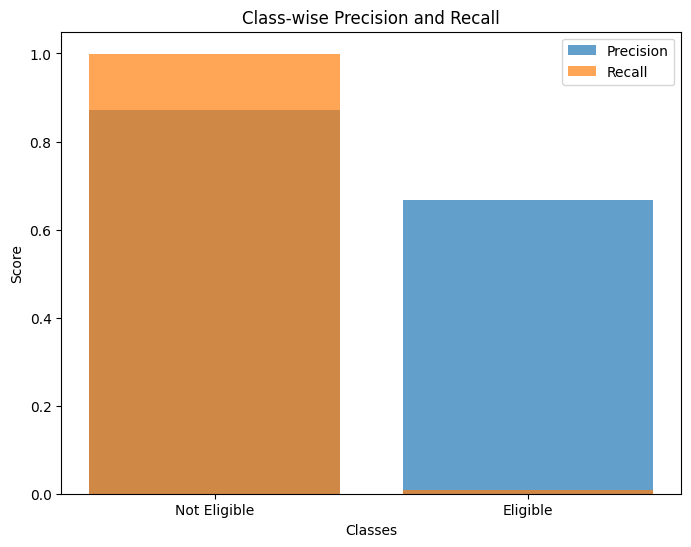

In [124]:
plt.figure(figsize=(8, 6))
plt.bar(range(2), precision_scores, label='Precision', alpha=0.7)
plt.bar(range(2), recall_scores, label='Recall', alpha=0.7)
plt.xticks(range(2), ['Not Eligible','Eligible'])
plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Class-wise Precision and Recall')
plt.legend()
plt.show()

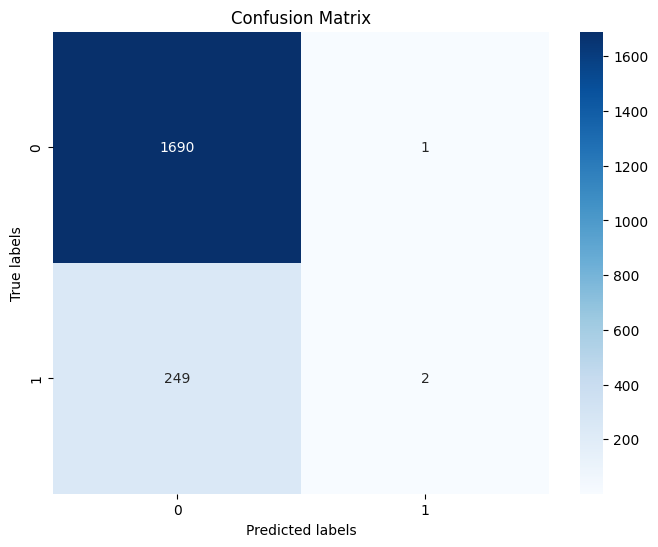

In [125]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

*   La Matriz de confusion nos dice que el algoritmo predijo correctamente 1690 0's, e incorrectamente un solo 0. Por otro lado, vemos que el algoritmo predijo 249 0's que en realidad son 1's. Y predijo correctamente solo dos 1's.
*   Como podemos ver, al estar trabajando con un DataFrame desbalanceado, por mas que utilizamos el algoritmo mas adecuado para analizar esta base de datos el algoritmo va a predecir por 0 en la mayoria de las veces.
*   En el caso de tener una base de datos desbalanceada, muy desbalanciada en este caso, es importante ver mas alla del accuracy. Este metodo tiene un accuracy de 87%, lo cual es considerable como optimo. Se puede observar, en la Matriz de Confusion, que el margen de error esta considerablemente inclinado a que el algoritmo predice un 0 cuando en realidad deberia ser un 1, y aun asi si solo vemos el accuracy, se deberia considerar al rendimiento del metodo de prediccion como optimo. Esto es asi ya que en nuestra base de datos la mayoria de nuestros datos de la variable objetivo Target son 0, entonces por mas que a al 99% de los datos de la variable target que son 1 los prediga como 0, va a ser un margen de error bajo, ya que la cantidad de 1's es muy baja.




# Conclusion


*   El modelo de Regresion Logistica demostro tener una precision de 87%  considerandose como un rendimiento alto en la predicción de la variable categórica Detección de tarjeta de crédito (elegible o no).
*   Aun asi, el modelo utilizado no es apto para su uso en estas instancias, ya que deberia pasar por un resampleo primero. Con el fin de balancear los datos. Ya que el modelo solo predice 0's en la mayoria de los casos.
*   Se decidio utilizar este modelo para identificar si es factible otorgarle la posibilidad de obtener credito a un cliente de alguna identidad bancaria con el fin de aumentar la presicion de eleccion y generar una solucion rapida y eficaz para el individuo o sector del comercio que este a cargo de la eleccion. De esta manera, con tan solo obtener los datos de las variables independientes tales como ingreso anual, si tiene vehiculo, etc. es posible predecir si un idividuo puede acceder a tener credito o no.
*   Para concluir, el modelo de clasificacion presentado, Random Forest Classifier, nos ofrece una herramienta prometedora para comprender y predecir si es factible otorgarle la posibilidad de obtener credito a un cliente de alguna identidad bancaria. (anulando que se deberia realizar un resampleo)



